# Hyperion: Interactive Hyperparameter Optimization Tutorial

Welcome to Hyperion! This notebook demonstrates the key features of Hyperion, an event-driven hyperparameter optimization framework.

## What You'll Learn

1. **Basic Usage**: How to use the simple `tune()` API
2. **Search Spaces**: Defining parameter distributions
3. **Strategies**: Comparing different optimization strategies
4. **Storage & Persistence**: Using SQLite for durable results
5. **Advanced Features**: Framework-level API and custom policies

## Prerequisites

```bash
# Install Hyperion (if not already installed)
pip install -e .
```

## 1. Setup and Imports

In [16]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
import time
import asyncio
from typing import Any

# Hyperion imports
from hyperion import tune, Float, Int, Choice, Bool, ObjectiveResult, TrialContext
from hyperion.visualization.terminal import TerminalVisualizer
from hyperion.storage.sql import SQLiteStores

# Set up plotting
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Hyperion imported successfully!")

✅ Hyperion imported successfully!


## 2. The Optimization Problem: Rastrigin Function

The Rastrigin function is a classic benchmark for optimization algorithms. It has many local minima, making it challenging to optimize.

$$f(x, y) = 20 + x^2 + y^2 - 10(\cos(2\pi x) + \cos(2\pi y))$$

The global minimum is at $(0, 0)$ with $f(0, 0) = 0$.

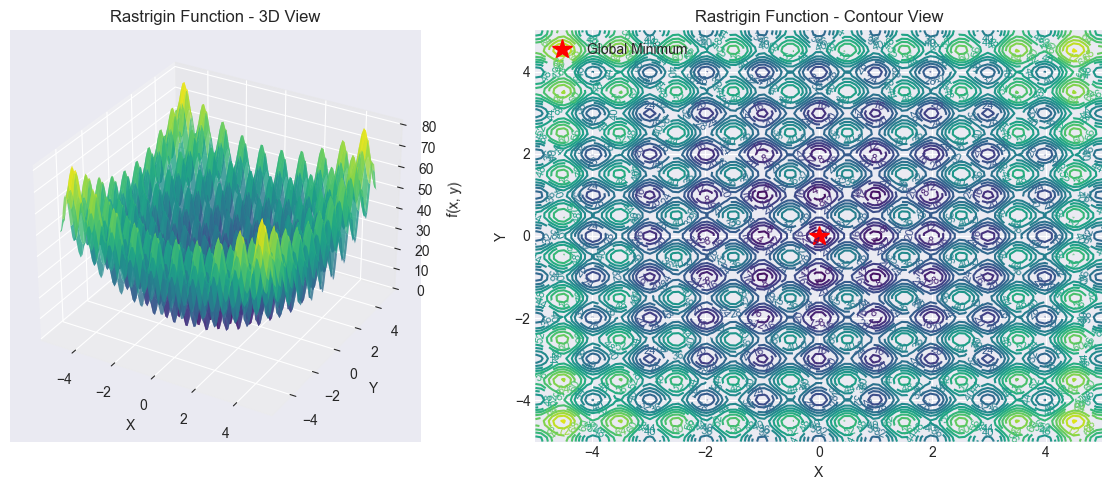

In [17]:
def rastrigin(x: float, y: float) -> float:
    """Rastrigin function - a challenging multi-modal optimization problem."""
    A = 10
    return 20 + x**2 + y**2 - A * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))


# Visualize the function
def plot_rastrigin():
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.array([[rastrigin(xi, yi) for xi in x] for yi in y])
    
    fig = plt.figure(figsize=(12, 5))
    
    # 3D surface plot
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.8)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('f(x, y)')
    ax1.set_title('Rastrigin Function - 3D View')
    
    # Contour plot
    ax2 = fig.add_subplot(122)
    contour = ax2.contour(X, Y, Z, levels=20, cmap=cm.viridis)
    ax2.clabel(contour, inline=True, fontsize=8)
    ax2.plot(0, 0, 'r*', markersize=15, label='Global Minimum')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_title('Rastrigin Function - Contour View')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_rastrigin()

## 3. Defining the Objective Function

In Hyperion, objective functions:
- Receive a `TrialContext` and hyperparameters
- Can report progress during execution
- Return an `ObjectiveResult` with the final score

We'll create an objective that:
1. Evaluates the Rastrigin function
2. Simulates computation time
3. Reports progress

In [18]:
def simple_objective(
    ctx: TrialContext,
    x: float,
    y: float,
    compute_time: float = 0.1
) -> ObjectiveResult:
    """Simple objective: minimize Rastrigin function."""
    
    # Simulate some computation
    time.sleep(compute_time)
    
    # Evaluate function (we want to minimize this)
    value = rastrigin(x, y)
    
    # Report progress
    ctx.report(step=0, value=value, x=x, y=y)
    
    # Return negative value since Hyperion maximizes by default
    return ObjectiveResult(
        score=-value,  # Negative because we want to minimize
        metrics={
            "rastrigin_value": value,
            "distance_from_optimum": np.sqrt(x**2 + y**2)
        }
    )


def advanced_objective(
    ctx: TrialContext,
    x: float,
    y: float,
    n_iterations: int = 5,
    noise_std: float = 0.1
) -> ObjectiveResult:
    """Advanced objective with multiple evaluations and noise."""
    
    values = []
    for i in range(n_iterations):
        # Add some noise to simulate real-world scenarios
        noise = np.random.normal(0, noise_std)
        value = rastrigin(x, y) + noise
        values.append(value)
        
        # Report progress
        ctx.report(step=i, iteration_value=value, mean_value=np.mean(values))
        
        # Check for early stopping
        if ctx.should_stop():
            break
        
        time.sleep(0.05)  # Simulate computation
    
    final_value = np.mean(values)
    
    return ObjectiveResult(
        score=-final_value,  # Negative to minimize
        metrics={
            "mean_value": final_value,
            "std_value": np.std(values),
            "n_evaluations": len(values),
            "distance_from_optimum": np.sqrt(x**2 + y**2)
        }
    )


print("✅ Objective functions defined!")

✅ Objective functions defined!


## 4. Basic Usage: Your First Optimization

Let's start with the simplest way to use Hyperion: the `tune()` function with random search.

In [19]:
# Define the search space
search_space = {
    "x": Float(-5.0, 5.0),  # Continuous float parameter
    "y": Float(-5.0, 5.0),
}

# Run optimization with random search
print("🚀 Starting random search optimization...\n")

result = tune(
    objective=simple_objective,
    space=search_space,
    strategy="random",
    max_trials=20,
    max_concurrent=2,
    show_progress=True,  # Show live progress
    show_summary=True,   # Show summary at end
)

# Display best result
best = result["best"]
print(f"\n🎯 Best parameters found:")
print(f"   x = {best['params']['x']:.4f}")
print(f"   y = {best['params']['y']:.4f}")
print(f"   Rastrigin value = {-best['score']:.4f}")
print(f"   Distance from optimum = {best['metrics']['distance_from_optimum']:.4f}")

🚀 Starting random search optimization...


🚀 Experiment Started: random
[08:21:21] ✅ Trial completed (1/2) Score: -33.0493
            Best so far: -33.0493
[08:21:21] ✅ Trial completed (2/2) Score: -57.6551
            Best so far: -33.0493
[08:21:21] ✅ Trial completed (3/4) Score: -33.4157
            Best so far: -33.0493
[08:21:21] ✅ Trial completed (4/5) Score: -56.0073
            Best so far: -33.0493
[08:21:21] ✅ Trial completed (5/6) Score: -36.7651
            Best so far: -33.0493
[08:21:21] ✅ Trial completed (6/7) Score: -33.7875
            Best so far: -33.0493
[08:21:21] ✅ Trial completed (7/8) Score: -49.0741
            Best so far: -33.0493
[08:21:21] ✅ Trial completed (8/8) Score: -57.1879
            Best so far: -33.0493
[08:21:22] ✅ Trial completed (9/10) Score: -47.3007
            Best so far: -33.0493
[08:21:22] ✅ Trial completed (10/11) Score: -32.6841
            Best so far: -32.6841
[08:21:22] ✅ Trial completed (11/12) Score: -41.1670
            Best so fa

## 5. Exploring Different Search Spaces

Hyperion supports various parameter distributions:

In [20]:
# Complex search space example
complex_space = {
    # Continuous distributions
    "x": Float(-5.0, 5.0),
    "y": Float(-5.0, 5.0),
    
    # Integer distribution
    "n_iterations": Int(3, 10),
    
    # Categorical choice
    "noise_std": Choice([0.01, 0.05, 0.1, 0.2]),
}

# Run with the advanced objective
print("🔍 Optimizing with complex search space...\n")

result = tune(
    objective=advanced_objective,
    space=complex_space,
    strategy="random",
    max_trials=15,
    max_concurrent=2,
    show_progress=True,
)

print(f"\n✅ Best configuration:")
for param, value in result["best"]["params"].items():
    print(f"   {param}: {value}")

🔍 Optimizing with complex search space...


🚀 Experiment Started: random
[08:21:22] ✅ Trial completed (1/2) Score: -33.9987
            Best so far: -33.9987
[08:21:23] ✅ Trial completed (2/3) Score: -63.5932
            Best so far: -33.9987
[08:21:23] ✅ Trial completed (3/4) Score: -24.6322
            Best so far: -24.6322
[08:21:23] ✅ Trial completed (4/5) Score: -49.8540
            Best so far: -24.6322
[08:21:23] ✅ Trial completed (5/6) Score: -14.4695
            Best so far: -14.4695
[08:21:23] ✅ Trial completed (6/7) Score: -32.1956
            Best so far: -14.4695
[08:21:23] ✅ Trial completed (7/8) Score: -38.3160
            Best so far: -14.4695
[08:21:24] ✅ Trial completed (8/9) Score: -41.2749
            Best so far: -14.4695
[08:21:24] ✅ Trial completed (9/10) Score: -55.1047
            Best so far: -14.4695
[08:21:24] ✅ Trial completed (10/11) Score: -14.7860
            Best so far: -14.4695
[08:21:24] ✅ Trial completed (11/12) Score: -39.6507
            Best so f

## 6. Comparing Different Strategies

Let's compare different optimization strategies on the same problem:

In [21]:
# Define a consistent search space
comparison_space = {
    "x": Float(-5.0, 5.0),
    "y": Float(-5.0, 5.0),
}

# Storage for persistent results
storage_url = "sqlite:///hyperion_comparison.db"

strategies_to_compare = [
    # Random Search - baseline
    {
        "name": "random",
        "kwargs": {},
        "color": "blue",
        "marker": "o"
    },
    
    # Grid Search - systematic exploration
    {
        "name": "grid",
        "kwargs": {
            "grid_values": {
                "x": [-4, -2, 0, 2, 4],
                "y": [-4, -2, 0, 2, 4],
            }
        },
        "color": "green",
        "marker": "s"
    },
    
    # Beam Search - tree-based exploration
    {
        "name": "beam_search",
        "kwargs": {
            "K": 3,           # Keep top 3 trials per depth
            "width": 2,       # Generate 2 children per parent  
            "max_depth": 3,   # Maximum tree depth
            "prune": False,   # Don't kill underperforming trials
        },
        "color": "red",
        "marker": "^"
    },
]

# Run comparisons
comparison_results = {}

for strategy_config in strategies_to_compare:
    strategy_name = strategy_config["name"]
    print(f"\n🚀 Running {strategy_name.upper()} strategy...")
    
    result = tune(
        objective=simple_objective,
        space=comparison_space,
        strategy=strategy_name,
        strategy_kwargs=strategy_config["kwargs"],
        max_trials=25,  # Grid will run exactly 25 trials (5x5 grid)
        max_concurrent=3,
        storage=storage_url,  # Persist results
        return_state=True,  # Return experiment ID
        show_progress=False,  # Suppress output for cleaner comparison
    )
    
    comparison_results[strategy_name] = result
    
    best = result["best"]
    print(f"   Best value found: {-best['score']:.4f} at ({best['params']['x']:.3f}, {best['params']['y']:.3f})")

print("\n✅ Comparison complete!")


🚀 Running RANDOM strategy...
   Best value found: 11.8054 at (1.939, -0.804)

🚀 Running GRID strategy...
   Best value found: -0.0000 at (0.000, 0.000)

🚀 Running BEAM_SEARCH strategy...
   Best value found: 10.2371 at (2.123, -0.124)

✅ Comparison complete!


## 7. Visualizing Strategy Performance

Let's visualize how different strategies explored the search space:

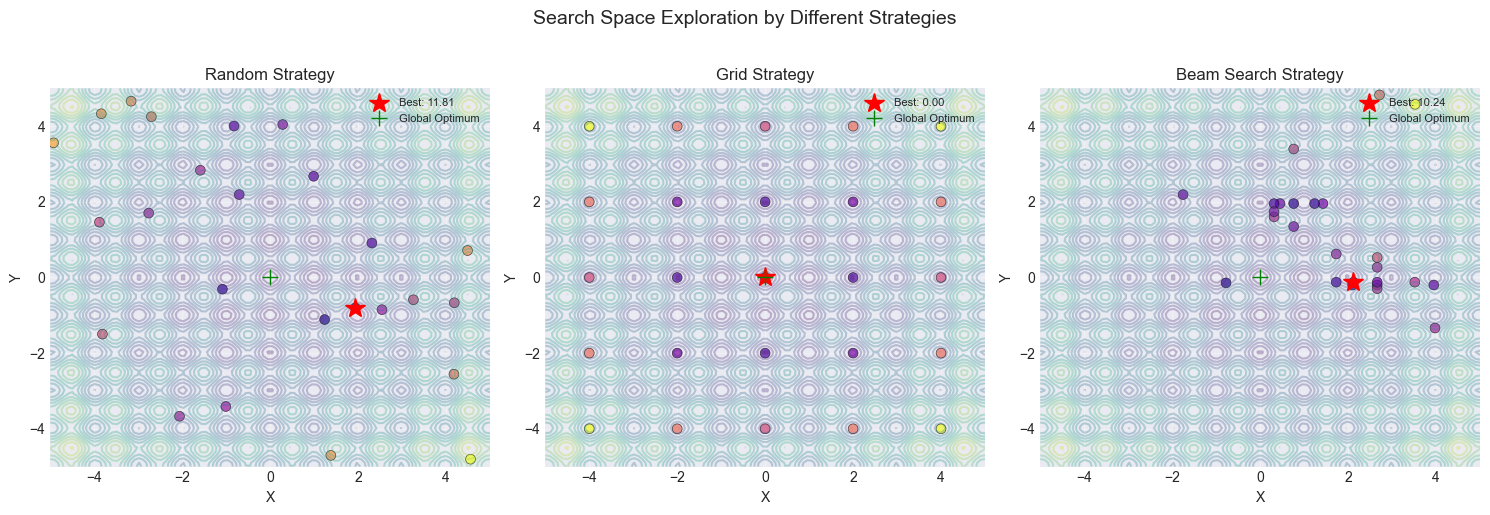

In [22]:
# Load trials from storage and visualize
stores = SQLiteStores(storage_url)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Background contour for all plots
x_bg = np.linspace(-5, 5, 100)
y_bg = np.linspace(-5, 5, 100)
X_bg, Y_bg = np.meshgrid(x_bg, y_bg)
Z_bg = np.array([[rastrigin(xi, yi) for xi in x_bg] for yi in y_bg])

for idx, (ax, strategy_config) in enumerate(zip(axes, strategies_to_compare)):
    strategy_name = strategy_config["name"]
    
    # Plot contour
    ax.contour(X_bg, Y_bg, Z_bg, levels=15, alpha=0.3, cmap='viridis')
    
    # Get experiment ID from comparison results
    if strategy_name in comparison_results:
        result = comparison_results[strategy_name]
        exp_id = result.get("experiment_id")
        
        if exp_id:
            # Get trials for this experiment
            trials = stores.trials.list_by_experiment(exp_id)
            
            # Extract x, y coordinates and scores
            xs = [t.params.get("x", 0) for t in trials if t.params]
            ys = [t.params.get("y", 0) for t in trials if t.params]
            scores = [-t.score if t.score else 0 for t in trials]
            
            # Plot trials
            if xs and ys:
                scatter = ax.scatter(xs, ys, 
                               c=scores, 
                               cmap='plasma', 
                               s=50, 
                               alpha=0.7,
                               edgecolors='black',
                               linewidth=0.5)
                
                # Mark best trial
                best_idx = np.argmin(scores)
                ax.plot(xs[best_idx], ys[best_idx], 
                       'r*', markersize=15, 
                       label=f'Best: {scores[best_idx]:.2f}')
    
    # Mark global optimum
    ax.plot(0, 0, 'g+', markersize=12, linewidth=2, label='Global Optimum')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'{strategy_name.replace("_", " ").title()} Strategy')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)

plt.suptitle('Search Space Exploration by Different Strategies', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Clean up
stores.close()

## 8. Using Persistent Storage

Hyperion can persist results to SQLite for later analysis:

In [23]:
# Run an experiment with persistent storage
storage_db = "sqlite:///hyperion_persistent.db"

print("💾 Running optimization with persistent storage...\n")

result = tune(
    objective=advanced_objective,
    space=complex_space,
    strategy="random",
    max_trials=10,
    max_concurrent=2,
    storage=storage_db,
    show_progress=True,
    return_state=True,  # Return experiment ID
)

experiment_id = result["experiment_id"]
print(f"\n📝 Experiment ID: {experiment_id}")

# Now we can query the stored results
stores = SQLiteStores(storage_db)

# Get experiment details
experiment = stores.experiments.get(experiment_id)
print(f"\n📊 Experiment Details:")
print(f"   Name: {experiment.name}")
print(f"   Status: {experiment.status}")
print(f"   Created: {experiment.created_at}")

# Get all trials
trials = stores.trials.list_by_experiment(experiment_id)
print(f"\n🔬 Trials Summary:")
print(f"   Total trials: {len(trials)}")
print(f"   Completed: {sum(1 for t in trials if t.status == 'COMPLETED')}")
print(f"   Failed: {sum(1 for t in trials if t.status == 'FAILED')}")

# Create a DataFrame for analysis
trial_data = []
for trial in trials:
    if trial.status == 'COMPLETED':
        trial_data.append({
            'trial_id': trial.id,
            'x': trial.params.get('x'),
            'y': trial.params.get('y'),
            'score': trial.score,
            'rastrigin_value': -trial.score if trial.score else None,
            'n_iterations': trial.params.get('n_iterations'),
            'noise_std': trial.params.get('noise_std'),
        })

df = pd.DataFrame(trial_data)
print("\n📈 Trial Results (Top 5 by Score):")
print(df.nlargest(5, 'score')[['x', 'y', 'rastrigin_value', 'n_iterations', 'noise_std']])

stores.close()

💾 Running optimization with persistent storage...


🚀 Experiment Started: random
[08:21:29] ✅ Trial completed (1/2) Score: -44.1215
            Best so far: -44.1215
[08:21:29] ✅ Trial completed (2/3) Score: -48.2036
            Best so far: -44.1215
[08:21:29] ✅ Trial completed (3/4) Score: -37.2184
            Best so far: -37.2184
[08:21:29] ✅ Trial completed (4/5) Score: -30.9501
            Best so far: -30.9501
[08:21:30] ✅ Trial completed (5/6) Score: -51.4506
            Best so far: -30.9501
[08:21:30] ✅ Trial completed (6/7) Score: -26.7661
            Best so far: -26.7661
[08:21:30] ✅ Trial completed (7/8) Score: -39.1116
            Best so far: -26.7661
[08:21:30] ✅ Trial completed (8/9) Score: -29.5340
            Best so far: -26.7661
[08:21:30] ✅ Trial completed (9/10) Score: -50.8434
            Best so far: -26.7661
[08:21:31] ✅ Trial completed (10/10) Score: -37.8799
            Best so far: -26.7661
🏁 Experiment Completed in 2.1s
   Trials: 10/10
   Best Score: -26

## 9. Advanced: Using the Terminal Visualizer

Hyperion includes a terminal visualizer for detailed experiment analysis:

In [24]:
# Use the terminal visualizer
stores = SQLiteStores(storage_db)
visualizer = TerminalVisualizer(stores)

# Print comprehensive summary
print("📊 Detailed Experiment Analysis:")
visualizer.print_summary(experiment_id, detailed=True)

# Print timeline of events (limited to 20 for brevity)
print("\n⏱️ Event Timeline:")
visualizer.print_timeline(experiment_id, limit=20)

stores.close()

📊 Detailed Experiment Analysis:

📊 EXPERIMENT SUMMARY: exp-c8da21d1

📋 Experiment: random
   Status: ExperimentStatus.COMPLETED
   Created: 2025-09-02 08:21:29.094010

📈 Statistics:
   Total Events: 118
   Trials Started: 10
   Trials Completed: 10
   Trials Failed: 0
   Decisions Made: 9

📝 Decision History:
------------------------------------------------------------
[08:21:29] RandomSearchPolicy
   💭 Random search: sampling uniformly from search space
   → Actions: 2 StartTrial
[08:21:29] RandomSearchPolicy
   💭 Random search: sampling uniformly from search space
   → Actions: 1 StartTrial
[08:21:29] RandomSearchPolicy
   💭 Random search: sampling uniformly from search space
   → Actions: 1 StartTrial
[08:21:29] RandomSearchPolicy
   💭 Random search: sampling uniformly from search space
   → Actions: 1 StartTrial
[08:21:29] RandomSearchPolicy
   💭 Random search: sampling uniformly from search space
   → Actions: 1 StartTrial
[08:21:30] RandomSearchPolicy
   💭 Random search: sampling

## 10. Framework-Level API: Advanced Control

For more control, you can use the framework-level API with `ExperimentSpec`:

In [25]:
from hyperion.framework import (
    ExperimentSpec,
    ExperimentRunner,
    Resources,
    Budget,
    Pipeline,
    Monitoring,
    create_services,
)
from hyperion.policies import BUILTIN

# Create a custom experiment specification
spec = ExperimentSpec(
    name="advanced_rastrigin_optimization",
    objective=advanced_objective,
    search_space=complex_space,
    pipeline=Pipeline(
        steps=[
            BUILTIN["random"](space=complex_space, experiment_id="advanced_exp")
        ]
    ),
    resources=Resources(
        max_concurrent=4,
        timeout_s=60,  # 1 minute timeout
    ),
    budget=Budget(
        max_trials=15,
        max_time_s=120,  # 2 minutes max
        metric="score",
        mode="max",
        target=None,  # Could set a target score to stop early
    ),
    monitoring=Monitoring(
        callbacks=[],  # Could add custom callbacks here
    ),
    tags={"tutorial": "framework_api", "problem": "rastrigin"},
)

# Create services using convenience function
services = create_services(
    storage="memory",
    max_concurrent=4,
    executor="async"
)

# Create and run the experiment
runner = ExperimentRunner(spec, services=services)

print("🎯 Running experiment with framework API...\n")

# Run asynchronously
result = await runner.run()

print(f"\n✅ Framework API Result:")
print(f"   Experiment: {result['experiment']}")
if 'best' in result and result['best']:
    print(f"   Best score: {result['best'].get('score', 'N/A')}")
    print(f"   Best params: {result['best'].get('params', {})}")

🎯 Running experiment with framework API...


✅ Framework API Result:
   Experiment: advanced_rastrigin_optimization
   Best score: -2.1460731543422766
   Best params: {'x': -0.006347340283773484, 'y': 0.10738774517304073, 'n_iterations': 7, 'noise_std': 0.1}


## 11. Interactive Parameter Explorer

Let's create an interactive way to explore how parameters affect the Rastrigin function:

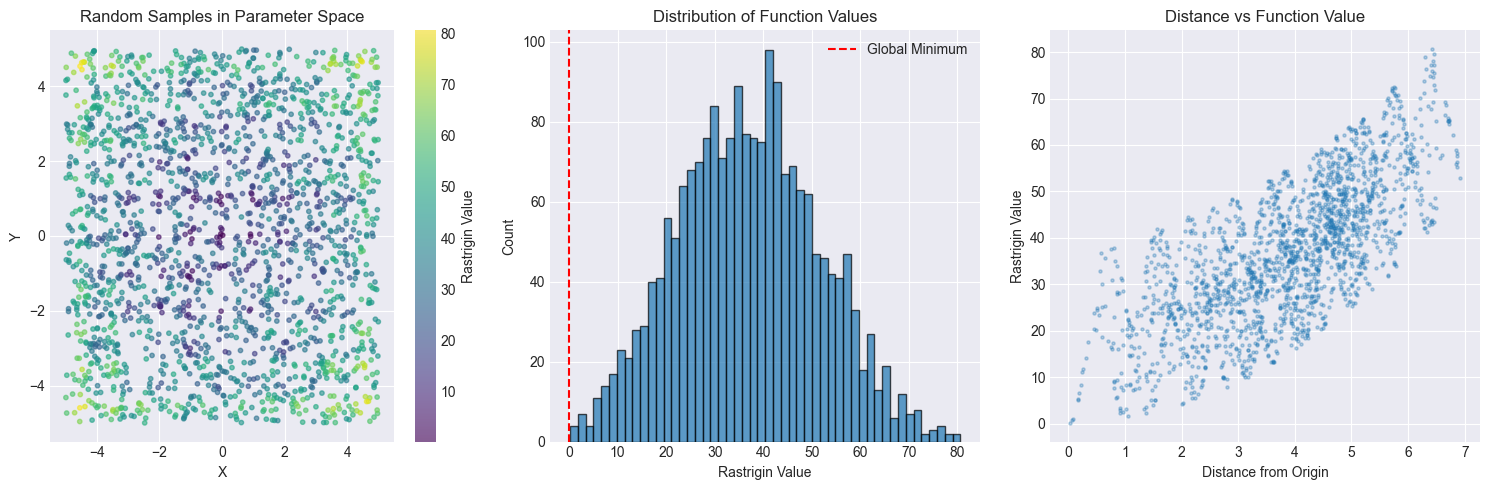

📊 Statistics from 2000 samples:
   Min value: 0.1642
   Max value: 80.6390
   Mean value: 36.9256
   Median value: 36.8299
   Samples near optimum (value < 5): 15


In [26]:
def explore_parameters(x_range=(-5, 5), y_range=(-5, 5), n_samples=1000):
    """Randomly sample and visualize parameter space."""
    
    # Generate random samples
    x_samples = np.random.uniform(x_range[0], x_range[1], n_samples)
    y_samples = np.random.uniform(y_range[0], y_range[1], n_samples)
    values = [rastrigin(x, y) for x, y in zip(x_samples, y_samples)]
    
    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Scatter plot colored by value
    ax1 = axes[0]
    scatter = ax1.scatter(x_samples, y_samples, c=values, 
                         cmap='viridis', s=10, alpha=0.6)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_title('Random Samples in Parameter Space')
    plt.colorbar(scatter, ax=ax1, label='Rastrigin Value')
    
    # Histogram of values
    ax2 = axes[1]
    ax2.hist(values, bins=50, edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Rastrigin Value')
    ax2.set_ylabel('Count')
    ax2.set_title('Distribution of Function Values')
    ax2.axvline(x=0, color='red', linestyle='--', label='Global Minimum')
    ax2.legend()
    
    # Distance vs Value relationship
    ax3 = axes[2]
    distances = [np.sqrt(x**2 + y**2) for x, y in zip(x_samples, y_samples)]
    ax3.scatter(distances, values, s=5, alpha=0.3)
    ax3.set_xlabel('Distance from Origin')
    ax3.set_ylabel('Rastrigin Value')
    ax3.set_title('Distance vs Function Value')
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"📊 Statistics from {n_samples} samples:")
    print(f"   Min value: {min(values):.4f}")
    print(f"   Max value: {max(values):.4f}")
    print(f"   Mean value: {np.mean(values):.4f}")
    print(f"   Median value: {np.median(values):.4f}")
    print(f"   Samples near optimum (value < 5): {sum(1 for v in values if v < 5)}")

# Explore the parameter space
explore_parameters(n_samples=2000)

## 12. Optimization Convergence Analysis

Let's analyze how different strategies converge over time:

 🔄 Running random (3 times)...


   Run 1: Best = 1.1266
   Run 2: Best = 11.6033
   Run 3: Best = 14.7045
 🔄 Running beam_search (3 times)...
   Run 1: Best = 15.7438
   Run 2: Best = 14.9281
   Run 3: Best = 5.9198


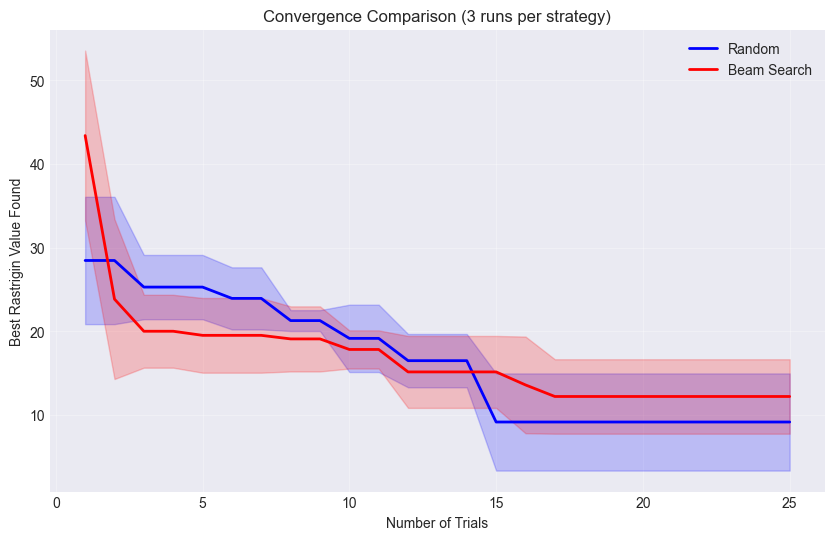

In [27]:
def run_convergence_analysis(n_runs=3, max_trials=30):
    """Compare convergence of different strategies."""
    
    strategies = ["random", "beam_search"]
    convergence_data = {s: [] for s in strategies}
    
    for strategy in strategies:
        print(f" 🔄 Running {strategy} ({n_runs} times)...")
        
        for run in range(n_runs):
            # Run optimization
            result = tune(
                objective=simple_objective,
                space={"x": Float(-5, 5), "y": Float(-5, 5)},
                strategy=strategy,
                strategy_kwargs={
                    "K": 3, "width": 2, "max_depth": 4
                } if strategy == "beam_search" else {},
                max_trials=max_trials,
                max_concurrent=2,
                storage=f"sqlite:///convergence_{strategy}_{run}.db",
                show_progress=False,
                return_state=True,  # Return experiment ID
            )
            
            # Extract convergence curve
            stores = SQLiteStores(f"sqlite:///convergence_{strategy}_{run}.db")
            exp_id = result.get("experiment_id")
            
            if exp_id:
                trials = stores.trials.list_by_experiment(exp_id)
            else:
                # No experiment ID returned, try empty list
                trials = []
                print(f"   Warning: No experiment_id for {strategy} run {run+1}")
            
            # Track best score over time
            best_scores = []
            current_best = float('inf')
            
            for trial in trials:
                if trial.score is not None:
                    # We're minimizing, so higher score (less negative) is worse
                    rastrigin_value = -trial.score
                    current_best = min(current_best, rastrigin_value)
                    best_scores.append(current_best)
            
            convergence_data[strategy].append(best_scores)
            stores.close()
            
            print(f"   Run {run+1}: Best = {current_best:.4f}")
    
    # Plot convergence curves
    plt.figure(figsize=(10, 6))
    
    colors = {'random': 'blue', 'beam_search': 'red'}
    
    for strategy in strategies:
        # Calculate mean and std across runs
        runs = convergence_data[strategy]
        if not runs or not any(runs):
            continue
            
        max_len = max(len(run) for run in runs if run)
        
        # Pad shorter runs with their final value
        padded_runs = []
        for run in runs:
            if run:  # Only process non-empty runs
                if len(run) < max_len:
                    padded = run + [run[-1]] * (max_len - len(run))
                else:
                    padded = run
                padded_runs.append(padded)
        
        if padded_runs:
            mean_curve = np.mean(padded_runs, axis=0)
            std_curve = np.std(padded_runs, axis=0)
            
            trials = np.arange(1, len(mean_curve) + 1)
            
            # Plot mean with confidence interval
            plt.plot(trials, mean_curve, label=strategy.replace('_', ' ').title(), 
                    color=colors[strategy], linewidth=2)
            plt.fill_between(trials, 
                            mean_curve - std_curve, 
                            mean_curve + std_curve,
                            color=colors[strategy], alpha=0.2)
    
    plt.xlabel('Number of Trials')
    plt.ylabel('Best Rastrigin Value Found')
    plt.title(f'Convergence Comparison ({n_runs} runs per strategy)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run convergence analysis
run_convergence_analysis(n_runs=3, max_trials=25)

## 13. Summary and Best Practices

### Key Takeaways

1. **Simple API**: The `tune()` function provides an easy entry point
2. **Flexible Search Spaces**: Support for continuous, integer, and categorical parameters
3. **Multiple Strategies**: Choose from random, grid, beam search, and more
4. **Persistence**: SQLite storage enables analysis and experiment resumption
5. **Event-Driven**: Advanced users can leverage the framework API for full control

### Best Practices

- **Start Simple**: Begin with random search to understand your problem
- **Use Appropriate Distributions**: Log-scale for learning rates, uniform for bounded parameters
- **Monitor Progress**: Enable `show_progress=True` for interactive sessions
- **Persist Important Experiments**: Use SQLite storage for reproducibility
- **Choose the Right Strategy**:
  - **Random**: Good baseline, works well with many trials
  - **Grid**: When you have discrete choices and want exhaustive search
  - **Beam Search**: For hierarchical exploration with pruning
  - **Bayesian**: When function evaluations are expensive (not shown here)

### Next Steps

- Try optimizing your own functions
- Experiment with LLM-based agents (requires Ollama)
- Build custom policies using the framework API
- Integrate with your ML training pipelines

Happy optimizing! 🚀

## Appendix: Cleanup

Remove temporary databases created during this tutorial:

In [28]:
import os
import glob

# List database files created
db_files = glob.glob("*.db")
print(f"Found {len(db_files)} database files:")
for db in db_files:
    size = os.path.getsize(db) / 1024  # Size in KB
    print(f"  - {db} ({size:.1f} KB)")

# Uncomment to clean up:
# for db in db_files:
#     os.remove(db)
#     print(f"Removed {db}")

Found 8 database files:
  - convergence_random_1.db (536.0 KB)
  - hyperion_persistent.db (912.0 KB)
  - hyperion_comparison.db (4028.0 KB)
  - convergence_random_0.db (864.0 KB)
  - convergence_beam_search_1.db (536.0 KB)
  - convergence_beam_search_0.db (536.0 KB)
  - convergence_beam_search_2.db (540.0 KB)
  - convergence_random_2.db (528.0 KB)
